In [38]:
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

# Data on the importance of religion in the lives of people in a particular country

In [30]:
importance = pd.read_csv('how-important-religion-is-in-your-life.csv')
importance.head()

,entity,code,year,very_important_in_life_religion,rather_important_in_life_religion,not_very_important_in_life_religion,notatall_important_in_life_religion,dont_know_important_in_life_religion,no_answer_important_in_life_religion,very_important_in_life_religion__annotations,rather_important_in_life_religion__annotations,not_very_important_in_life_religion__annotations,notatall_important_in_life_religion__annotations,dont_know_important_in_life_religion__annotations,no_answer_important_in_life_religion__annotations
0,Albania,ALB,1998,24.22422,34.534530,28.228230,10.71071,2.302302,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,ALB,2004,27.50000,31.200000,25.200000,14.20000,1.900000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,Albania,ALB,2010,15.71519,35.645400,27.452140,18.17237,1.967477,1.047418,NaN,NaN,NaN,NaN,NaN,NaN
3,Albania,ALB,2022,24.36961,48.684380,15.685870,10.84857,0.061695,0.349869,NaN,NaN,NaN,NaN,NaN,NaN
4,Algeria,DZA,2004,90.63963,7.488299,0.936037,NaN,0.936037,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
importance.isna().sum() / len(importance)

entity                                               0.0000
code                                                 0.0100
year                                                 0.0000
very_important_in_life_religion                      0.0000
rather_important_in_life_religion                    0.0000
not_very_important_in_life_religion                  0.0025
notatall_important_in_life_religion                  0.0175
dont_know_important_in_life_religion                 0.0125
no_answer_important_in_life_religion                 0.0000
very_important_in_life_religion__annotations         0.9900
rather_important_in_life_religion__annotations       0.9900
not_very_important_in_life_religion__annotations     0.9900
notatall_important_in_life_religion__annotations     0.9900
dont_know_important_in_life_religion__annotations    0.9900
no_answer_important_in_life_religion__annotations    0.9900
dtype: float64

**The last 6 columns contain too many nans, so we can safely delete them** 

In [32]:
importance.drop(['very_important_in_life_religion__annotations', 
                'rather_important_in_life_religion__annotations',
                'not_very_important_in_life_religion__annotations',
                'notatall_important_in_life_religion__annotations',
                'dont_know_important_in_life_religion__annotations',
                'no_answer_important_in_life_religion__annotations'],
                axis=1, 
                inplace=True)

In [35]:
importance.rename({'very_important_in_life_religion': 'very',
                  'rather_important_in_life_religion': 'rather',
                  'not_very_important_in_life_religion': 'not_very',
                  'notatall_important_in_life_religion': 'notatall',
                  'dont_know_important_in_life_religion': 'dont_know',
                  'no_answer_important_in_life_religion': 'no_answer'}, 
                  axis=1,
                  inplace=True)

In [36]:
importance.describe()

,year,very,rather,not_very,notatall,dont_know,no_answer
count,400.000000,400.000000,400.000000,399.000000,393.000000,395.000000,400.000000
mean,2008.862500,39.708636,24.618583,20.540174,13.907680,1.071966,0.461093
std,9.553101,28.743844,11.042982,13.376816,13.056979,2.220445,1.268939
min,1993.000000,1.400000,0.909580,0.005463,0.011139,0.000000,0.000000
25%,2004.000000,15.027638,16.509105,8.788017,3.060705,0.053072,0.000000
50%,2010.000000,30.519690,25.448380,21.929670,9.959350,0.330788,0.083333
75%,2014.000000,59.146822,32.066985,31.176890,22.500000,1.084608,0.528669
max,2022.000000,98.891770,56.801590,60.383380,75.800000,24.253770,17.275750


**There are no values greater than 100% or less than zero anywhere. Everything is fine.**

In [40]:
importance['total'] = (importance[['very', 
                                 'rather',
                                 'not_very',
                                 'notatall',
                                 'dont_know',
                                 'no_answer']]
                       .sum(axis=1))

print(importance['total'].min())
print(importance['total'].max())

99.9999856
100.000013


**The total for this line is expected to be 100%. Everything is fine.**

In [41]:
print(len(importance['entity'].unique()))
importance['entity'].unique()

117


array(['Albania', 'Algeria', 'Andorra', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Azerbaijan', 'Bangladesh', 'Belarus',
       'Belgium', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil',
       'Bulgaria', 'Burkina Faso', 'Canada', 'Chile', 'China', 'Colombia',
       'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Dominican Republic',
       'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Ethiopia',
       'Finland', 'France', 'Georgia', 'Germany', 'Ghana', 'Greece',
       'Guatemala', 'Haiti', 'Hong Kong', 'Hungary', 'Iceland', 'India',
       'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Italy', 'Japan', 'Jordan',
       'Kazakhstan', 'Kenya', 'Kosovo', 'Kuwait', 'Kyrgyzstan', 'Latvia',
       'Lebanon', 'Libya', 'Lithuania', 'Luxembourg', 'Macao', 'Malaysia',
       'Maldives', 'Mali', 'Malta', 'Mexico', 'Moldova', 'Mongolia',
       'Montenegro', 'Morocco', 'Myanmar', 'Netherlands', 'New Zealand',
       'Nicaragua', 'Nigeria', 'North Macedonia', 'Northern Cyprus',
       'Nort

**We have data on 117 countries. They are listed above**

<Axes: ylabel='Count'>

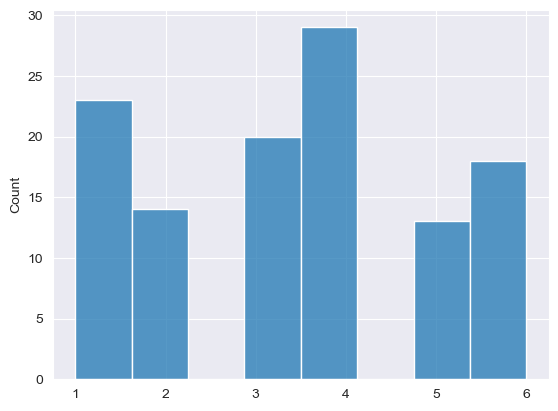

In [44]:
entries_by_year = importance.groupby('entity').size().sort_values()

sns.histplot(entries_by_year)

**We have an unbalanced number of entries by year for each country. The minimum number is 1, and the maximum is 6.**

## Outliers checking

To avoid overloading the notebook, let’s keep only the columns where there were actual outliers

### no_answer

<Axes: ylabel='no_answer'>

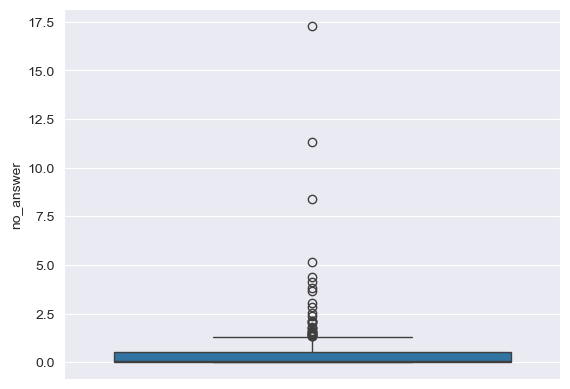

In [60]:
sns.boxplot(importance['no_answer'])

**Let's check three top outliers**

In [75]:
importance.sort_values('no_answer', ascending=False)[
    ['entity', 'no_answer']
    ].head(3)

,entity,no_answer
188,Latvia,17.275750
173,Japan,11.313870
353,Tanzania,8.368916


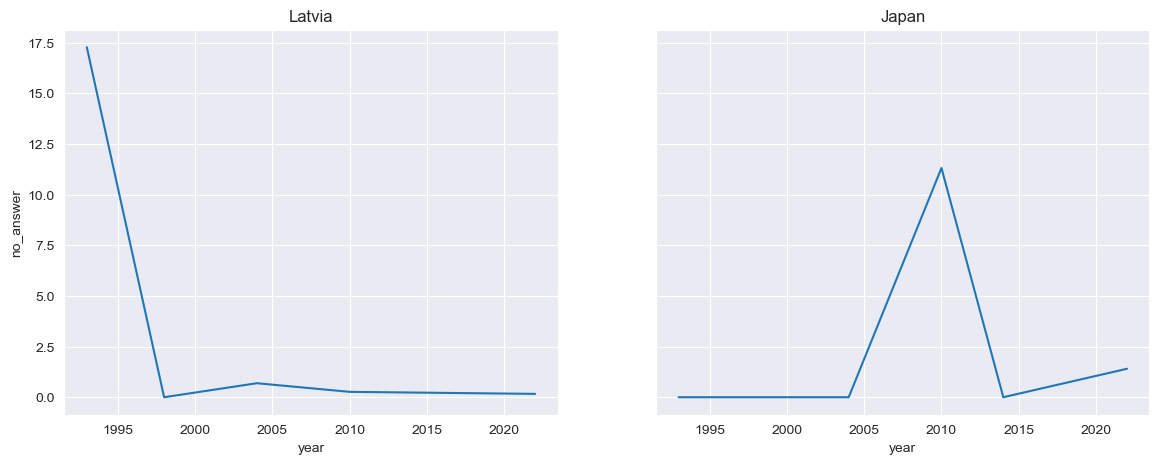

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, code, title in zip(axes, ['LVA', 'JPN'], ['Latvia', 'Japan']):
    sns.lineplot(
        data=importance[importance['code'] == code],
        x='year',
        y='no_answer',
        ax=ax
    )
    
    ax.set_title(title)

plt.show()

This outliers look actually strange. There is no such trend here

**Tanzania**

In [62]:
importance[
    importance['entity'] == 'Tanzania'
][['year', 'no_answer']]

,year,no_answer
353,2004,8.368916


There's only one entry here, so we can't really talk about any kind of trend

## don't know

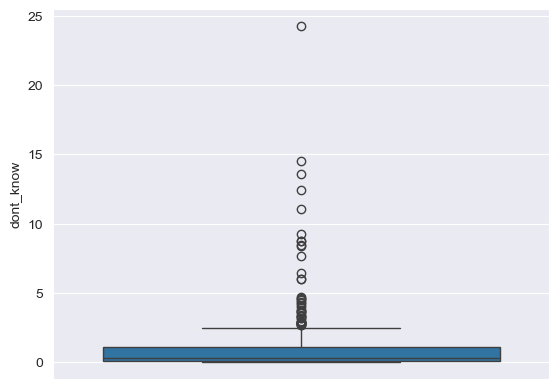

In [80]:
sns.boxplot(importance['dont_know'])
plt.show()

Let's look at the five tallest ones, because the rest aren't quite as tall

In [89]:
importance.sort_values('dont_know', ascending=False)[
    ['entity', 'year', 'dont_know']
    ].head(5)

,entity,year,dont_know
70,China,2010,24.25377
170,Japan,1993,14.54006
174,Japan,2014,13.54891
172,Japan,2004,12.40822
68,China,1998,11.06667


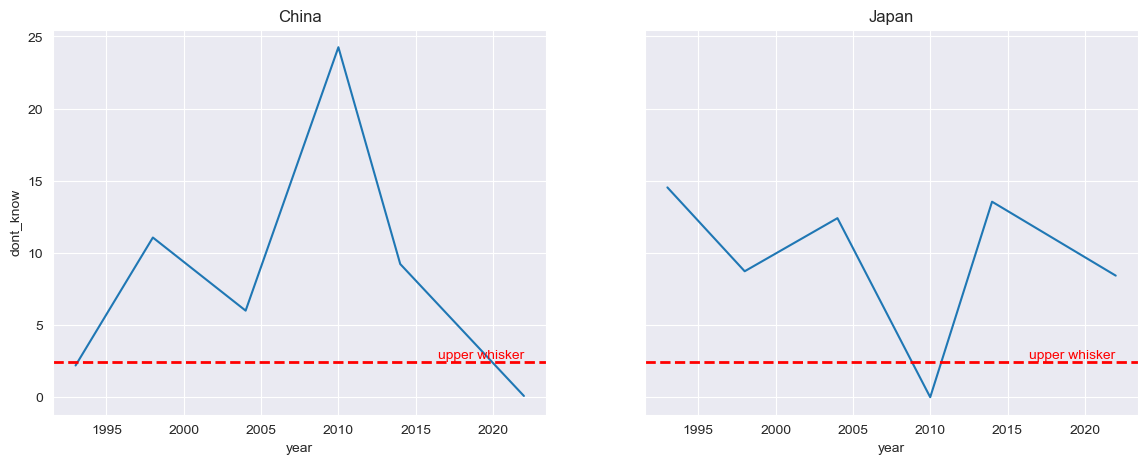

In [99]:
q1_dont_know = importance['dont_know'].quantile(0.25)
q3_dont_know = importance['dont_know'].quantile(0.75)
iqr_dont_know = q3_dont_know - q1_dont_know

upper_bound_dont_know = q3_dont_know + 1.5 * iqr_dont_know

upper_whisker_dont_know = importance.loc[
    importance['dont_know'] <= upper_bound_dont_know,
    'dont_know'
].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, country in zip(axes, ['China', 'Japan']):
    sns.lineplot(
        data=importance[importance['entity'] == country],
        x='year',
        y='dont_know',
        ax=ax
    )
    
    ax.axhline(
        y=upper_whisker_dont_know,
        color='red',
        linestyle='--',
        linewidth=2
    )
    
    ax.text(
        x=importance['year'].max(),
        y=upper_whisker_dont_know,
        s='upper whisker',
        color='red',
        ha='right',
        va='bottom'
    )
    
    ax.set_title(country)

plt.show()

That seems reasonable, since there’s a trend here showing that people in Japan and China are more likely than others to answer “I don’t know.”